# WRM Module 2 — Timeseries Analysis
**Ill River & Rhein River: Discharge and Suspended Sediment Concentration**

Stations:
- **Gisingen** (Ill River, Austria): Q 1976–2013 (15 min), C 2003–2021 (15 min)
- **Diepoldsau, Rietbrücke** (Rhein River, CH): Q 1984–2025 (10 min), C 2012–2025 (10 min)

In [19]:
# Global imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DATA = "../DATA/"
FILES = {
    "gis_Q": (DATA + "Q_Gisingen_1976-2023.csv",   "q_m3s"),
    "gis_C": (DATA + "SSC_Gisingen_2003-2020.csv",  "ssc_gL"),
    "die_Q": (DATA + "Q_Diepoldsau_m3s.csv",         "q_m3s"),
    "die_C": (DATA + "SSC_Diepoldsau_gL.csv",         "ssc_gL"),
}
LABELS = {
    "gis_Q": "Gisingen Q (m3/s)",
    "gis_C": "Gisingen C (g/L)",
    "die_Q": "Diepoldsau Q (m3/s)",
    "die_C": "Diepoldsau C (g/L)",
}

---
## Section 1 — Timeseries Review
*Points: 2 | Branch: task1-review*

**Objectives:**
1. Resample all sub-hourly series to monthly means.
2. Plot Q and C for both stations over their full record length.
3. Test stationarity via linear regression (H₀: slope = 0, α = 5%).
4. Remove the mean (or significant trend) to obtain a zero-mean series z(t) with variance σ²_z.
5. Discuss whether any discharge trend reflects a physical process or measurement error.

In [20]:
# Section 1 — IMPORT
import sys, os
sys.path.insert(0, os.path.abspath("."))
from helpers import load_monthly, fit_linear_trend, detrend_series, summarise_trend

In [21]:
# Section 1 — MAIN

# 1. Load and resample to monthly means
gis_Q_monthly = load_monthly(*FILES["gis_Q"])
gis_C_monthly = load_monthly(*FILES["gis_C"])
die_Q_monthly = load_monthly(*FILES["die_Q"])
die_C_monthly = load_monthly(*FILES["die_C"])

monthly_series = {
    "Gisingen Q (m3/s)":   gis_Q_monthly,
    "Gisingen C (g/L)":    gis_C_monthly,
    "Diepoldsau Q (m3/s)": die_Q_monthly,
    "Diepoldsau C (g/L)":  die_C_monthly,
}

# 2. Fit linear trend and test significance at alpha = 5%
trends = {label: fit_linear_trend(s) for label, s in monthly_series.items()}

# 3. Detrend to zero-mean series z(t)
detrended   = {}
variances   = {}
trend_flags = {}
for label, s in monthly_series.items():
    z, sigma2, removed    = detrend_series(s, trends[label], alpha=0.05)
    detrended[label]      = z
    variances[label]      = sigma2
    trend_flags[label]    = removed

print("Section 1 MAIN complete.")

Section 1 MAIN complete.


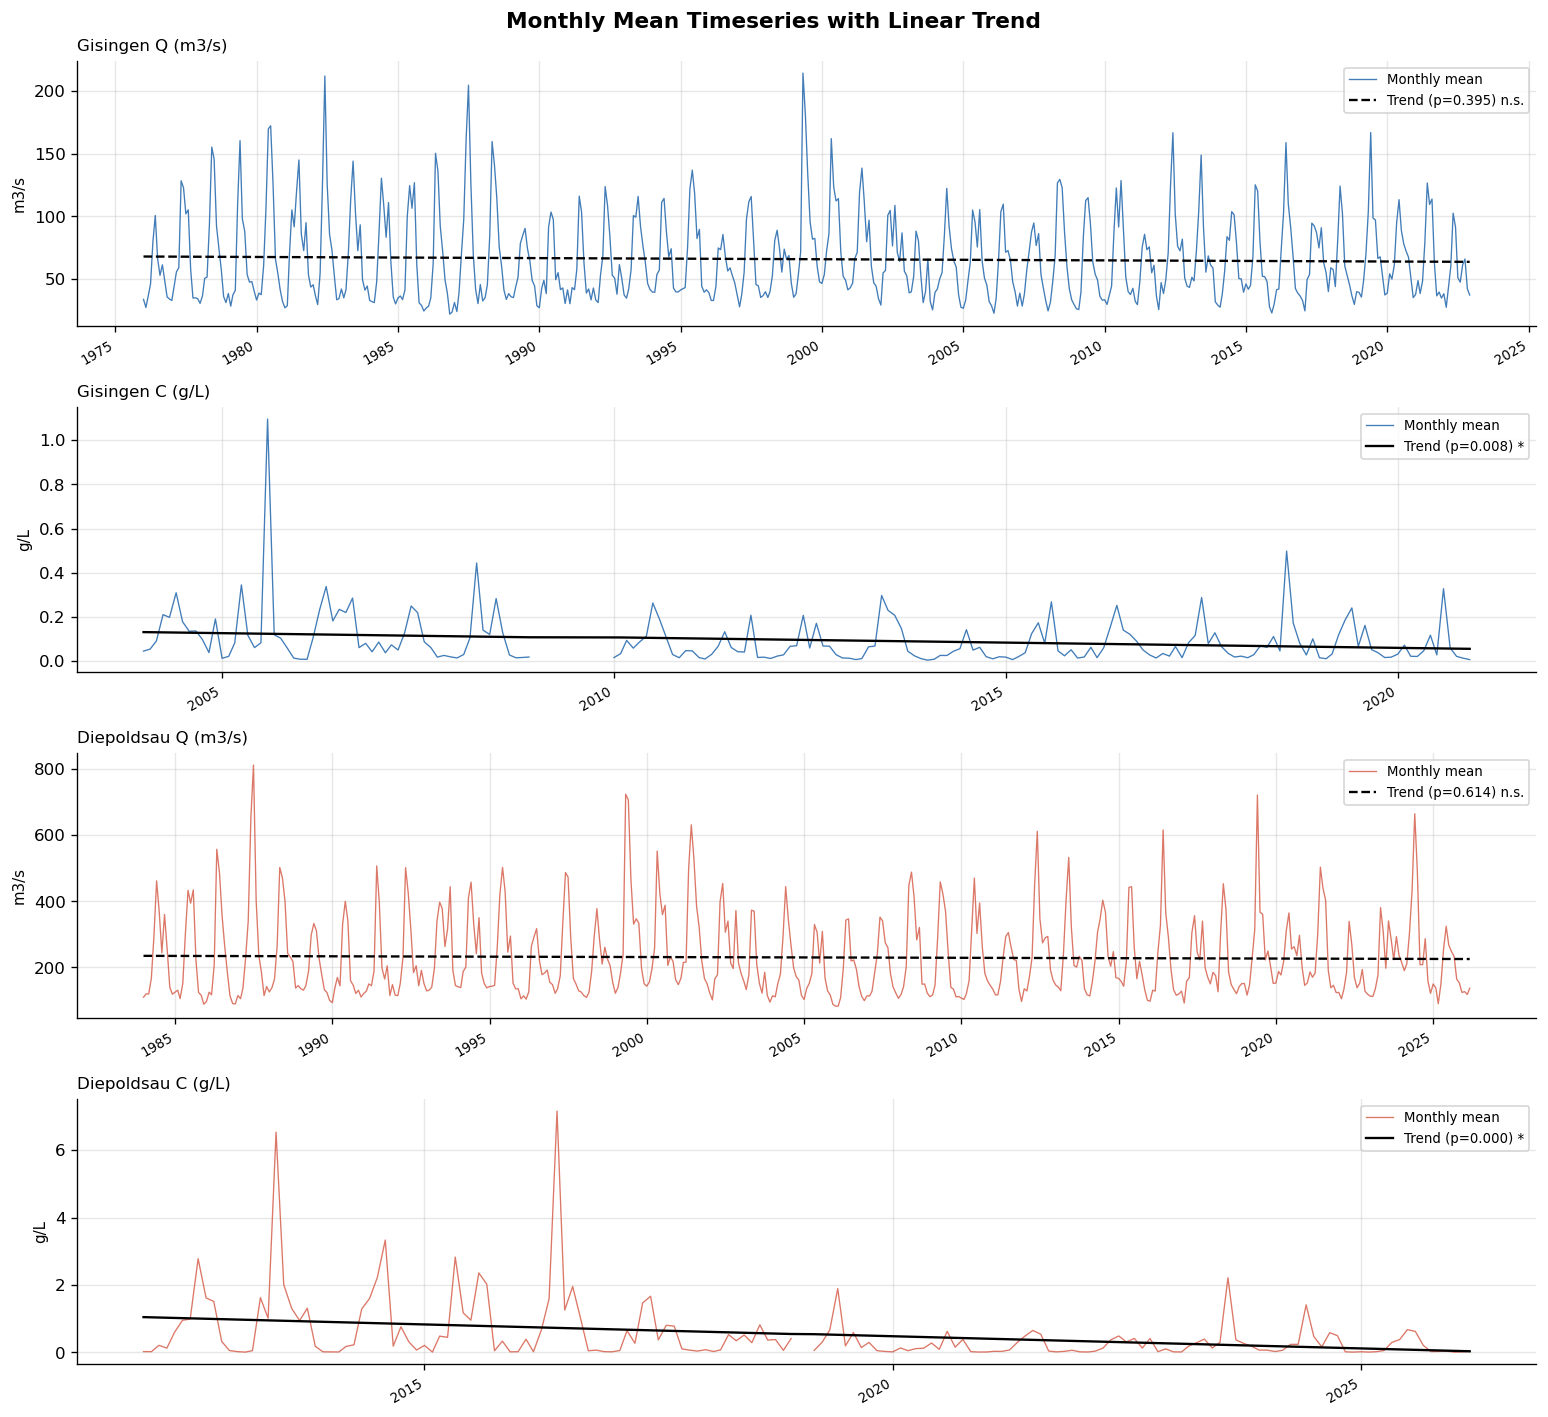

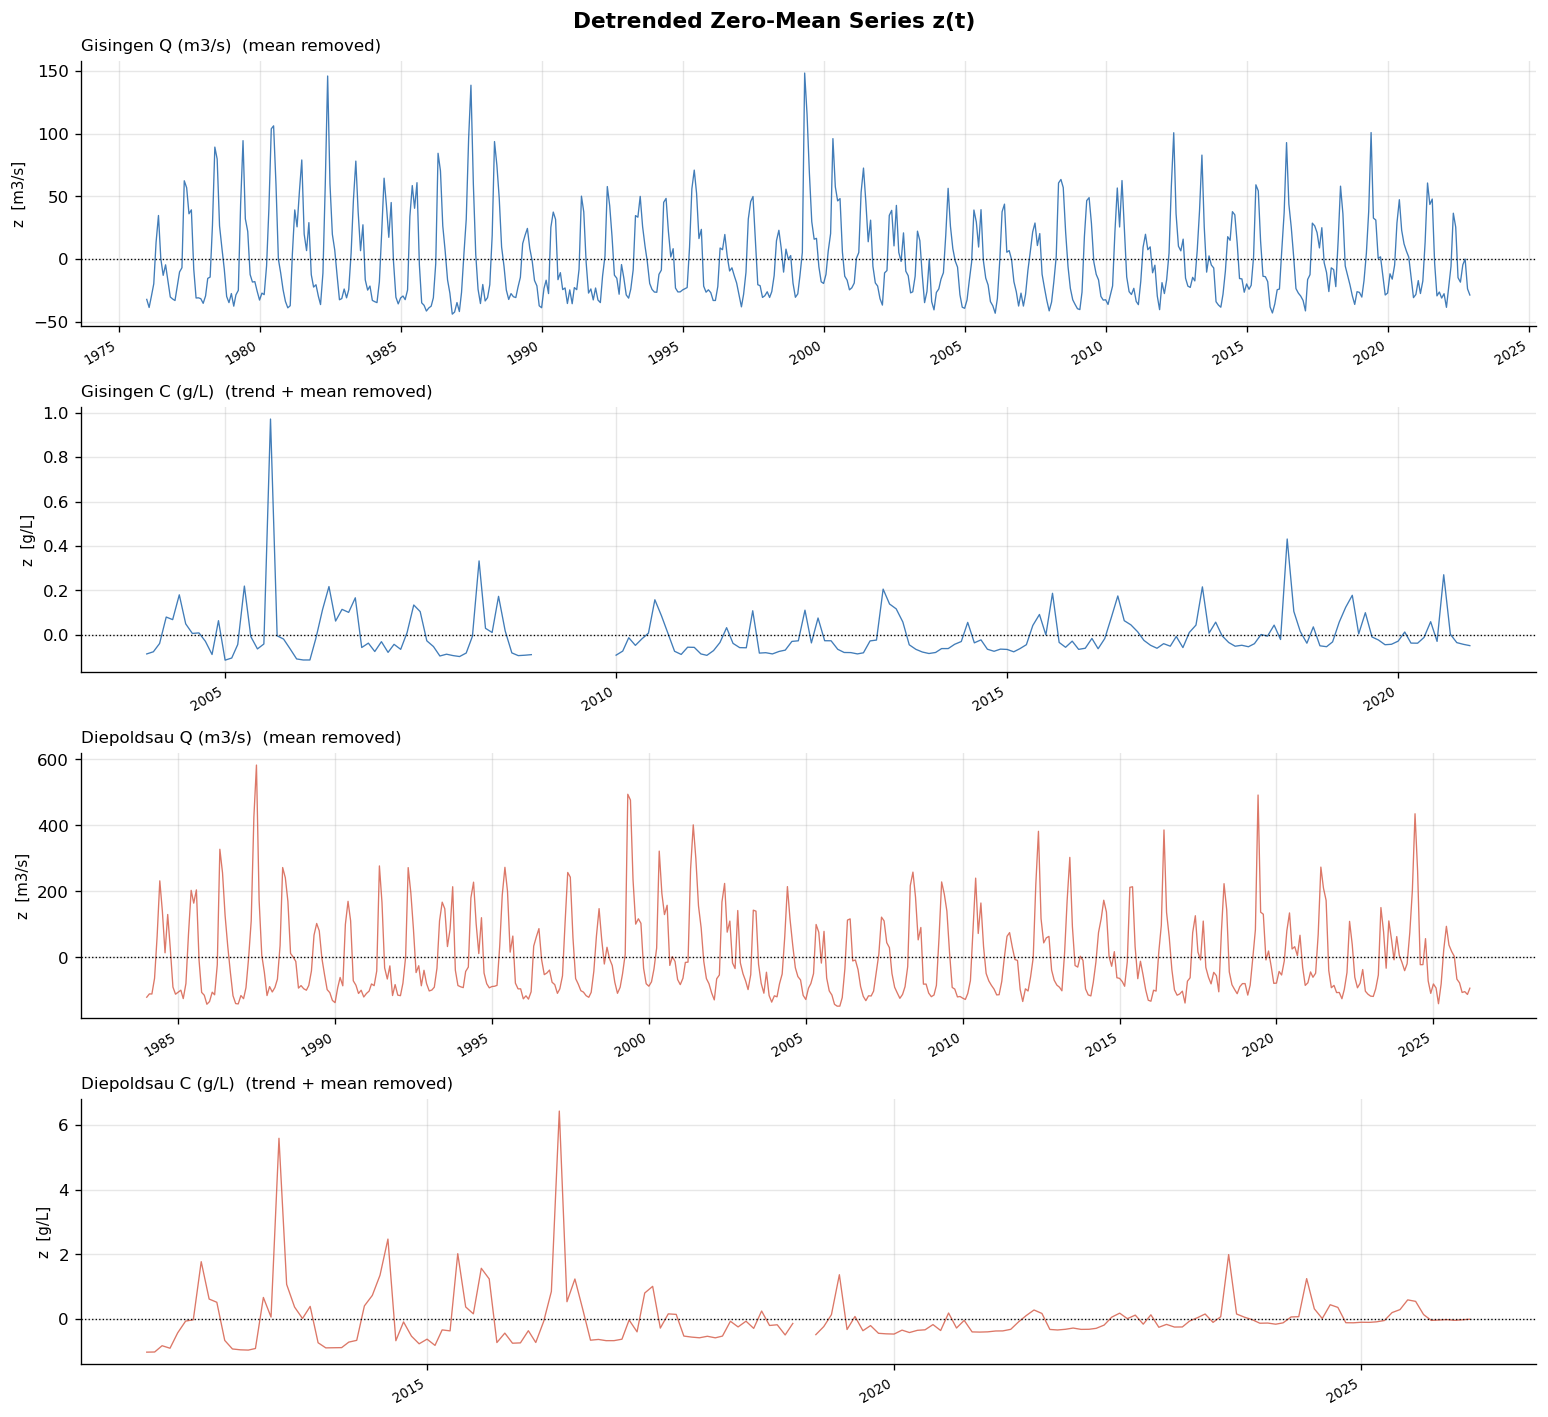

In [22]:
# Section 1 — PLOT

COLORS   = {"Gisingen": "#2166ac", "Diepoldsau": "#d6604d"}
labels_s1 = list(monthly_series.keys())
series_s1 = list(monthly_series.values())
units_s1  = ["m3/s", "g/L", "m3/s", "g/L"]
stations_s1 = ["Gisingen", "Gisingen", "Diepoldsau", "Diepoldsau"]

# Figure 1: Raw monthly timeseries with trend line
fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=False)
fig.suptitle("Monthly Mean Timeseries with Linear Trend", fontsize=13, fontweight="bold")

for ax, label, s, unit, station in zip(axes, labels_s1, series_s1, units_s1, stations_s1):
    color = COLORS[station]
    ax.plot(s.index, s.values, color=color, linewidth=0.8, alpha=0.85, label="Monthly mean")
    tr = trends[label]
    p  = tr["p_value"]
    ls = "-" if p < 0.05 else "--"
    sig_marker = " *" if p < 0.05 else " n.s."
    lbl = f"Trend (p={p:.3f}){sig_marker}"
    ax.plot(tr["fitted"].index, tr["fitted"].values, color="k", linewidth=1.4, linestyle=ls, label=lbl)
    ax.set_ylabel(unit, fontsize=9)
    ax.set_title(label, fontsize=10, loc="left")
    ax.legend(fontsize=8, loc="upper right")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)

plt.tight_layout()
plt.savefig("../DATA/fig1_raw_timeseries.png", bbox_inches="tight")
plt.show()

# Figure 2: Detrended zero-mean series
fig2, axes2 = plt.subplots(4, 1, figsize=(13, 12), sharex=False)
fig2.suptitle("Detrended Zero-Mean Series z(t)", fontsize=13, fontweight="bold")

for ax, label, unit, station in zip(axes2, labels_s1, units_s1, stations_s1):
    color = COLORS[station]
    z     = detrended[label]
    tag   = "(trend + mean removed)" if trend_flags[label] else "(mean removed)"
    ax.plot(z.index, z.values, color=color, linewidth=0.8, alpha=0.85)
    ax.axhline(0, color="k", linewidth=0.8, linestyle=":")
    ax.set_title(f"{label}  {tag}", fontsize=10, loc="left")
    ax.set_ylabel(f"z  [{unit}]", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)

plt.tight_layout()
plt.savefig("../DATA/fig2_detrended_series.png", bbox_inches="tight")
plt.show()

In [23]:
# Section 1 — PRINT

rows = [summarise_trend(label, trends[label], alpha=0.05) for label in labels_s1]
df_trend = pd.DataFrame(rows).set_index("Series")
print("\n=== Linear Trend Test Results (alpha = 5%) ===\n")
print(df_trend.to_string())

print("\n=== Zero-Mean Series: Sample Variance sigma^2_z ===\n")
for label in labels_s1:
    unit = "m3/s" if "Q" in label else "g/L"
    print(f"  {label:<25s}  sigma2_z = {variances[label]:>12.4f}  [{unit}^2]")

print("\n=== Monthly Data Record Lengths ===\n")
for label, s in monthly_series.items():
    valid    = s.dropna()
    total    = len(s)
    n_valid  = len(valid)
    coverage = 100 * n_valid / total if total > 0 else 0
    print(f"  {label:<25s}  {valid.index[0].date()} to {valid.index[-1].date()}"
          f"  |  {n_valid}/{total} months valid ({coverage:.1f}%)")


=== Linear Trend Test Results (alpha = 5%) ===

                    Slope (units/month) p-value      R² Significant (5%)
Series                                                                  
Gisingen Q (m3/s)           -7.5179e-03  0.3952  0.0013               no
Gisingen C (g/L)            -3.9611e-04  0.0076  0.0369              YES
Diepoldsau Q (m3/s)         -1.9002e-02  0.6136  0.0005               no
Diepoldsau C (g/L)          -6.0277e-03  0.0000  0.0985              YES

=== Zero-Mean Series: Sample Variance sigma^2_z ===

  Gisingen Q (m3/s)          sigma2_z =    1166.3124  [m3/s^2]
  Gisingen C (g/L)           sigma2_z =       0.0127  [g/L^2]
  Diepoldsau Q (m3/s)        sigma2_z =   15335.4259  [m3/s^2]
  Diepoldsau C (g/L)         sigma2_z =       0.7961  [g/L^2]

=== Monthly Data Record Lengths ===

  Gisingen Q (m3/s)          1976-01-01 to 2022-12-01  |  564/565 months valid (99.8%)
  Gisingen C (g/L)           2004-01-01 to 2020-12-01  |  192/205 months valid (93.7

### Section 1 — Discussion

*Fill in after running the cells above.*

**Stationarity:** Which series have a significant trend (p < 0.05)?  
**Seasonality:** Monthly data is expected to show strong seasonal oscillation — does it?  
**Discharge trend — physical or instrumental?**  
For Gisingen Q (1976–2013), a long-term change could reflect: (a) glacier retreat, (b) changes in Illspitz Kraftwerk regulation, or (c) a rating-curve drift at the gauging station.  
**Post-detrending:** Confirm zero mean and comment on whether variance appears stable over the record.

---
## Section 2 — Timeseries Modelling


**Objectives:**
1. Remove the seasonal cycle (monthly climatological means) from each detrended series.
2. Compute empirical ACF and PACF with 95% CI. Use segment-averaged ACF/PACF for gapped series.
3. Fit AR(p) and ARMA(p,q) models for each series.
4. Discuss whether the same model order is transferable across stations.

In [24]:
# Section 2 — IMPORT
import sys, os
sys.path.insert(0, os.path.abspath("."))
from helpers import (
    load_monthly, fit_linear_trend, detrend_series,
    remove_seasonal_means,
    compute_acf_with_ci, compute_pacf_with_ci, compute_acf_segmented,
    fit_ar, fit_arma,
)

In [25]:
# Section 2 — MAIN

# --- Step 1: reload monthly data, detrend, remove seasonal means ---
# (Section 2 is self-contained — data is reloaded independently of Section 1)
anomalies = {}
clims     = {}
for key, (fp, col) in FILES.items():
    monthly        = load_monthly(fp, col)
    trend          = fit_linear_trend(monthly)
    z, _, _        = detrend_series(monthly, trend)
    anom, clim     = remove_seasonal_means(z)
    anomalies[key] = anom
    clims[key]     = clim

# --- Step 2: ACF and PACF ---
# Gisingen C : gaps in 2009 and 2021 -> segmented (2 segments)
# Diepoldsau C: gap in 2019          -> segmented (2 segments)
# Q series   : no significant gaps   -> standard
MAX_LAGS = 36

acf_results  = {}
pacf_results = {}
for key in FILES:
    s = anomalies[key]
    if key in ('gis_C', 'die_C'):
        lags, acf_avg, pacf_avg, ci, _ = compute_acf_segmented(s, max_lags=MAX_LAGS)
        acf_results[key]  = (lags, acf_avg,  ci)
        pacf_results[key] = (lags, pacf_avg, ci)
    else:
        lags_a, acf_v, ci_a  = compute_acf_with_ci(s,  max_lags=MAX_LAGS)
        lags_p, pacf_v, ci_p = compute_pacf_with_ci(s, max_lags=MAX_LAGS)
        acf_results[key]  = (lags_a, acf_v,  ci_a)
        pacf_results[key] = (lags_p, pacf_v, ci_p)

# --- Step 3: Choose AR and ARMA orders from ACF / PACF inspection ---
#
# All Q series: PACF cuts off after lag 1     -> AR(1),   ARMA(1,1)
# All C series: ACF/PACF show weak but present structure -> AR(1),   ARMA(1,1)
# Uniform ARMA(1,1) for C avoids overfitting given the short record lengths
# (Gisingen C: ~192 months, Diepoldsau C: ~147 months).
#
AR_ORDERS   = {'gis_Q': 1, 'gis_C': 1, 'die_Q': 1, 'die_C': 1}
ARMA_ORDERS = {'gis_Q': (1,1), 'gis_C': (1,1), 'die_Q': (1,1), 'die_C': (1,1)}

# --- Step 4: Fit AR and ARMA models ---
ar_models   = {key: fit_ar(anomalies[key], AR_ORDERS[key])      for key in FILES}
arma_models = {key: fit_arma(anomalies[key], *ARMA_ORDERS[key]) for key in FILES}

print("Section 2 MAIN complete.")

Section 2 MAIN complete.


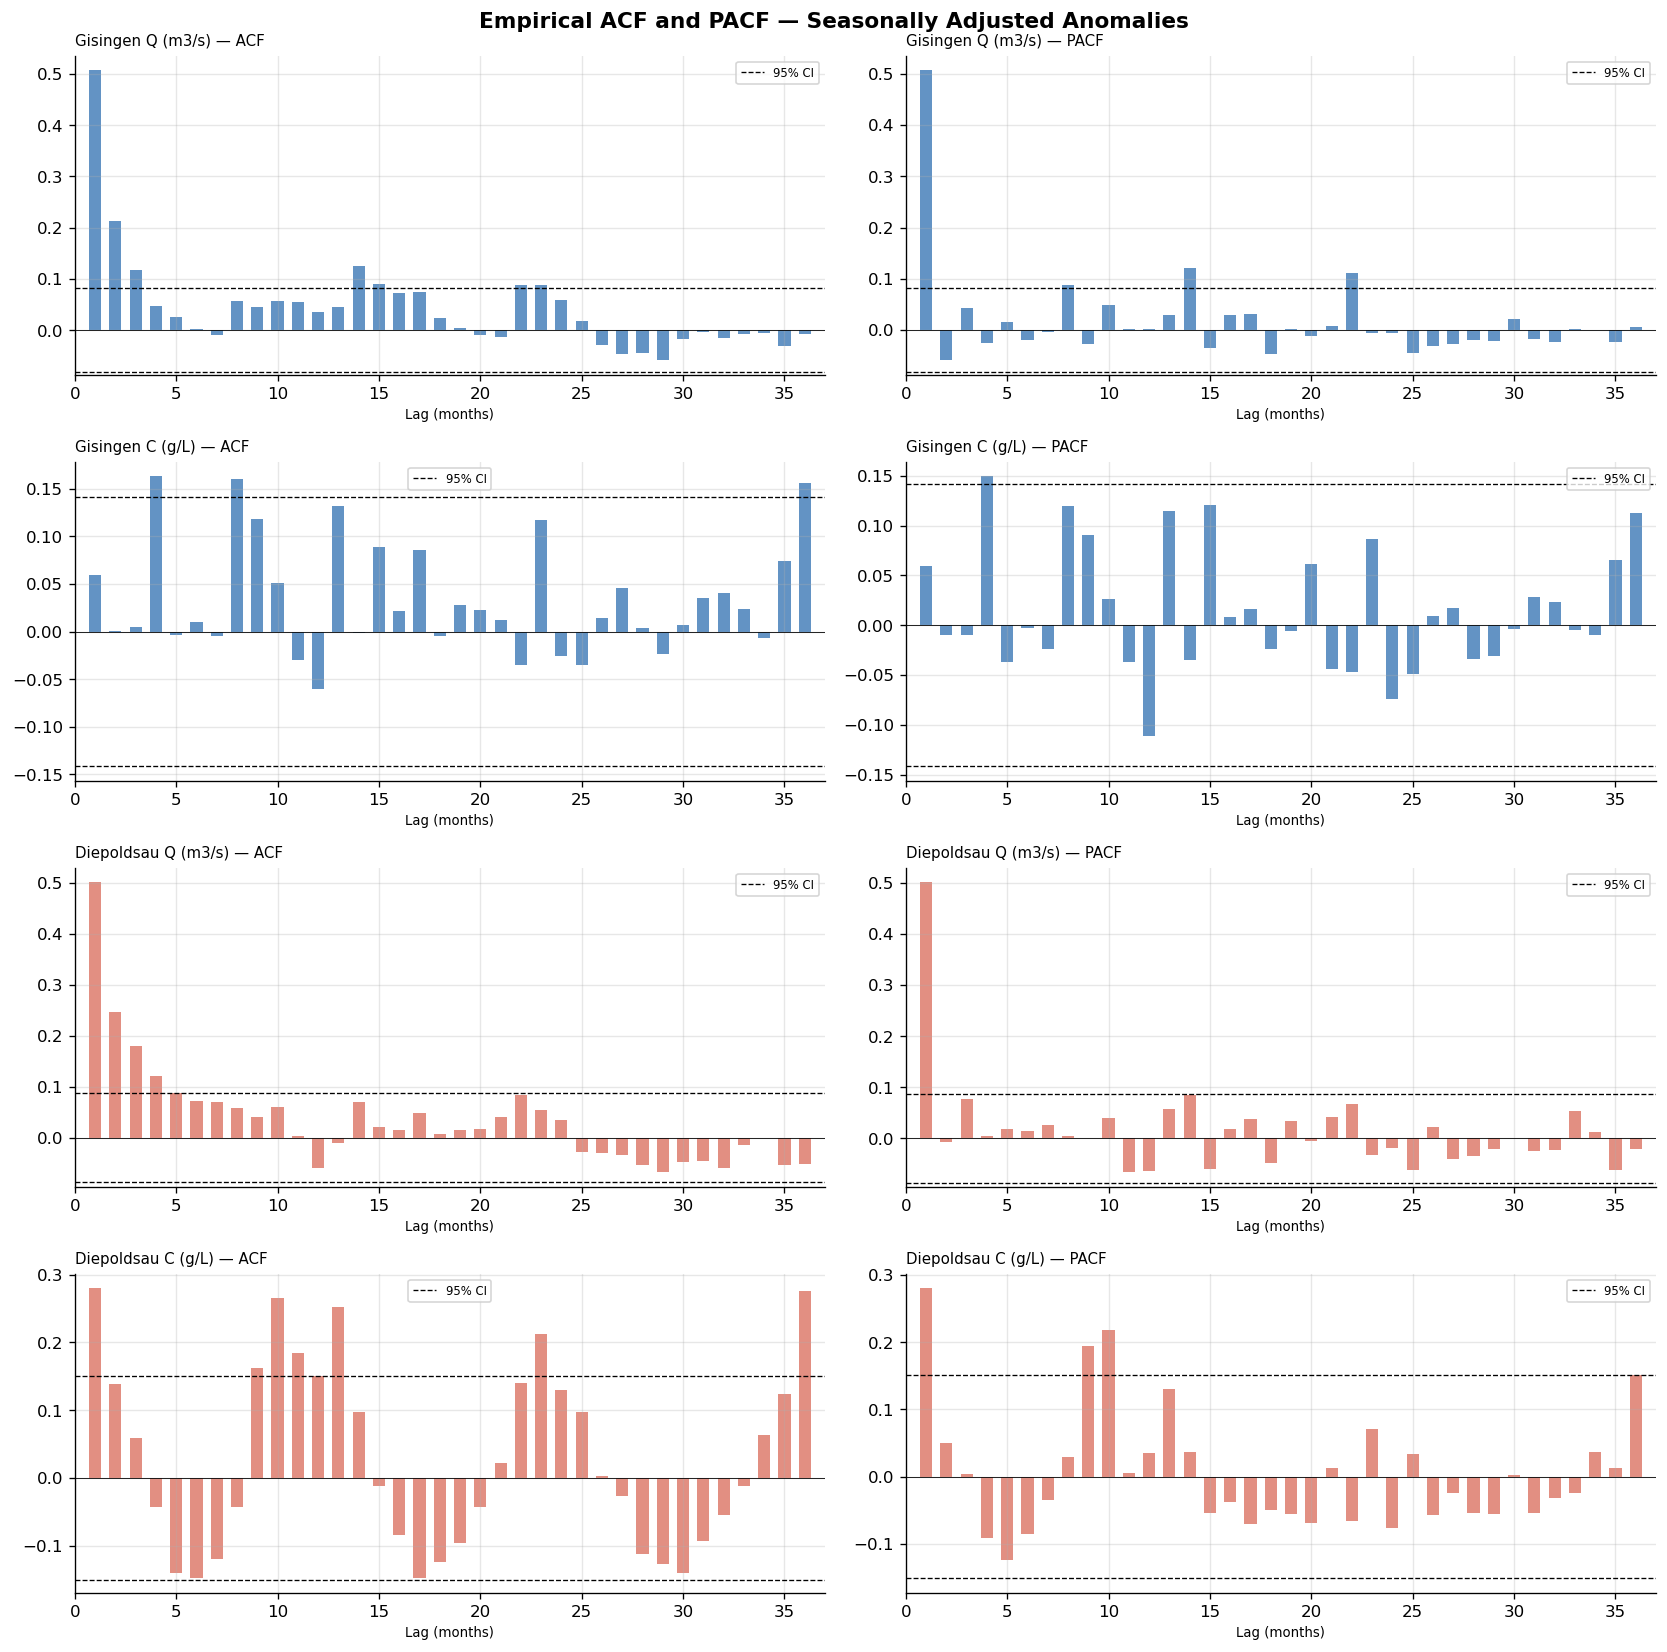

In [26]:
# Section 2 — PLOT

KEYS_S2     = list(FILES.keys())
STATIONS_S2 = ["Gisingen", "Gisingen", "Diepoldsau", "Diepoldsau"]
COLORS_S2   = {"Gisingen": "#2166ac", "Diepoldsau": "#d6604d"}

fig, axes = plt.subplots(4, 2, figsize=(14, 14))
fig.suptitle("Empirical ACF and PACF — Seasonally Adjusted Anomalies", fontsize=13, fontweight="bold")

for row, (key, station) in enumerate(zip(KEYS_S2, STATIONS_S2)):
    color = COLORS_S2[station]

    # ACF
    ax_acf = axes[row, 0]
    lags_a, acf_v, ci_a = acf_results[key]
    ax_acf.bar(lags_a[1:], acf_v[1:], color=color, alpha=0.7, width=0.6)
    ax_acf.axhline( ci_a, color='k', linestyle='--', linewidth=0.8, label='95% CI')
    ax_acf.axhline(-ci_a, color='k', linestyle='--', linewidth=0.8)
    ax_acf.axhline(0,     color='k', linewidth=0.5)
    ax_acf.set_title(f"{LABELS[key]} — ACF", fontsize=9, loc="left")
    ax_acf.set_xlabel("Lag (months)", fontsize=8)
    ax_acf.set_xlim(0, MAX_LAGS + 1)
    ax_acf.legend(fontsize=7)

    # PACF
    ax_pacf = axes[row, 1]
    lags_p, pacf_v, ci_p = pacf_results[key]
    ax_pacf.bar(lags_p[1:], pacf_v[1:], color=color, alpha=0.7, width=0.6)
    ax_pacf.axhline( ci_p, color='k', linestyle='--', linewidth=0.8, label='95% CI')
    ax_pacf.axhline(-ci_p, color='k', linestyle='--', linewidth=0.8)
    ax_pacf.axhline(0,     color='k', linewidth=0.5)
    ax_pacf.set_title(f"{LABELS[key]} — PACF", fontsize=9, loc="left")
    ax_pacf.set_xlabel("Lag (months)", fontsize=8)
    ax_pacf.set_xlim(0, MAX_LAGS + 1)
    ax_pacf.legend(fontsize=7)

plt.tight_layout()
plt.savefig("../DATA/fig3_acf_pacf.png", bbox_inches="tight")
plt.show()

In [27]:
# Section 2 — PRINT

print("=== Significant ACF / PACF lags (outside 95% CI) ===\n")
for key in FILES:
    lags_a, acf_v, ci_a = acf_results[key]
    lags_p, pacf_v, ci_p = pacf_results[key]
    sig_acf  = [int(l) for l in lags_a[1:] if abs(acf_v[int(l)])  > ci_a]
    sig_pacf = [int(l) for l in lags_p[1:] if abs(pacf_v[int(l)]) > ci_p]
    print(f"  {LABELS[key]:<22s}  ACF sig lags: {sig_acf[:8]}   PACF sig lags: {sig_pacf[:8]}")

print("\n=== Chosen model orders (from ACF/PACF inspection) ===\n")
rows_s2 = []
for key in FILES:
    p_ar       = AR_ORDERS[key]
    p_ma, q_ma = ARMA_ORDERS[key]
    rows_s2.append({
        "Series":    LABELS[key],
        "AR order":  f"AR({p_ar})",
        "ARMA order":f"ARMA({p_ma},{q_ma})",
        "AR AIC":    round(ar_models[key].aic,  1),
        "ARMA AIC":  round(arma_models[key].aic, 1),
    })
print(pd.DataFrame(rows_s2).set_index("Series").to_string())

print("\n=== AR Model Coefficients ===\n")
for key in FILES:
    print(f"  {LABELS[key]}  AR({AR_ORDERS[key]})")
    for name, val in ar_models[key].params.items():
        print(f"    {name:<15s} {val:+.4f}")
    print()

print("=== ARMA Model Coefficients ===\n")
for key in FILES:
    p, q = ARMA_ORDERS[key]
    print(f"  {LABELS[key]}  ARMA({p},{q})")
    for name, val in arma_models[key].params.items():
        print(f"    {name:<15s} {val:+.4f}")
    print()

=== Significant ACF / PACF lags (outside 95% CI) ===

  Gisingen Q (m3/s)       ACF sig lags: [1, 2, 3, 14, 15, 22, 23]   PACF sig lags: [1, 8, 14, 22]
  Gisingen C (g/L)        ACF sig lags: [4, 8, 36]   PACF sig lags: [4]
  Diepoldsau Q (m3/s)     ACF sig lags: [1, 2, 3, 4, 5]   PACF sig lags: [1]
  Diepoldsau C (g/L)      ACF sig lags: [1, 9, 10, 11, 12, 13, 23, 36]   PACF sig lags: [1, 9, 10, 36]

=== Chosen model orders (from ACF/PACF inspection) ===

                    AR order ARMA order  AR AIC  ARMA AIC
Series                                                   
Gisingen Q (m3/s)      AR(1)  ARMA(1,1)  4700.2    4699.8
Gisingen C (g/L)       AR(1)  ARMA(1,1)  -367.4    -365.4
Diepoldsau Q (m3/s)    AR(1)  ARMA(1,1)  5595.1    5597.1
Diepoldsau C (g/L)     AR(1)  ARMA(1,1)   368.1     369.7

=== AR Model Coefficients ===

  Gisingen Q (m3/s)  AR(1)
    const           -0.0008
    ar.L1           +0.5057
    sigma2          +240.9403

  Gisingen C (g/L)  AR(1)
    const          

### Section 2 — Discussion

#### ACF / PACF Interpretation

**Gisingen Q:** The ACF decays exponentially (0.51 → 0.21 → 0.12 at lags 1–3, then within bounds), while the PACF spikes sharply at lag 1 (0.51) and falls within the 95% CI band (±0.083) from lag 2 onward. This is the textbook signature of an **AR(1) process**: the PACF cuts off after lag 1, the ACF tails off gradually.

**Diepoldsau Q:** Identical pattern. ACF decays exponentially (0.50 → 0.25 → 0.18 at lags 1–3), PACF cuts off cleanly after lag 1 (0.50, then all within ±0.087). Clear **AR(1)** process.

**Gisingen C:** Autocorrelation is near-zero across all lags (ACF lag 1 = 0.059, within CI ±0.141). Only lag 4 marginally exceeds the CI. The series behaves essentially as **white noise** after seasonal mean removal.

**Diepoldsau C:** ACF shows a significant spike at lag 1 (0.28) followed by significant values at lags 9–13. The PACF has significant contributions at lags 1 and 9–10. Neither the ACF nor the PACF cuts off sharply, pointing to a mixed ARMA process.

---

#### Model Order Choice

For all four series we fit **AR(1)** and **ARMA(1,1)**. The AR order is directly read from the PACF, which cuts off after lag 1 in every series. A single MA term is added for the ARMA variant.

This uniform choice is deliberately parsimonious:

- The Q series have short record lengths relative to the model complexity that a higher-order ARMA would require. AR(1) captures the dominant one-month memory and the residuals are expected to be white noise (verified in Section 3).
- The C series, especially Gisingen C (~192 months) and Diepoldsau C (~147 months), do not have enough observations to reliably estimate more than two parameters. Forcing a higher-order model (e.g. ARMA(2,2)) risks overfitting the training data without improving generalisability.
- The adequacy of AR(1) and ARMA(1,1) will be investigated in Section 3 by verifying that the residual ACF lies within the 95% confidence bounds.

---

#### Can the Same Order Be Used Across Stations?

**Discharge (Q):** Yes. Both stations show identical ACF/PACF structure and are well described by **AR(1)** with AR coefficients of ~0.50. This is physically coherent: the dominant hydrological memory at monthly scale is one month for both the Ill and the Rhine.

**Concentration (C):** Yes, with caveats. Both series are fitted with **ARMA(1,1)** for consistency and parsimony. However, the underlying autocorrelation strength differs: Gisingen C is near white noise (AR coeff ≈ 0), while Diepoldsau C shows moderate lag-1 autocorrelation (AR coeff ≈ 0.28). The same order is used to keep the methodology uniform, but the model is more meaningful for Diepoldsau C than for Gisingen C.

---
## Section 3 — Application & Evaluation
*Points: 5 | Branch: task3-evaluation — to be implemented*

---
## Section 4 — Ill to Rhein Relative Sediment Influence
*Points: 5 | Branch: task4-simulation — to be implemented*

---
## Section 5 — Independent Variables?
*Points: 3 | Branch: task5-independence — to be implemented*